In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from Autograd import Tensor
from Loss import cross_entropy_loss
from Transformer import Transformer
from Optimiser import Adam
from Training import text_training,text_generate_batch
from Tiny_Shakespeare_Data_Prep import data_read
from Model_saving import save_model,load_model
from Testing import generate_text

When training on text, it is important to think about which tokens are important in the context block. The attention mechanism was introduced to address this issue.

Given an embedding of the tokens $x$ we apply a no bias term linear transformation to each batch to find the query, $Q$, key, $K$, and value, $V$. These weights are learned by gradient descent. If $x$ is a single batch, where each row is the token+position embedding of the token, then each row of $Q$,$K$ and $V$ are the queries/keys/values respectively.

We can interpret the query as a representation of what information we are looking for, the key as what information is contained in the corresponding token and the value as the information that should be 'provided' once deemed useful.

An example of where this is useful is considering the word 'bank'. It can refer to either a financial institution or the edge of a river. The surrounding context around the word tells us which 'bank' we are talking about in english. The attention mechanism is used to measure which tokens are useful for the next representation. 

In general given a query and a set of (key,value) pairs, we aim to find weights for each value vector, where the weights are found using the query and keys.
$$Attention(\bold{q})=\sum_i \alpha(\bold{q},k_i) v_i$$
The value vector with higher weight will have greater affect on the output evidently; the learned transformations to find the queries, keys and values are indirectly optimised such that we produce attention weights which reduce the loss. 

Whilst $\alpha$ has many choices, the most commonly used is the dot products between query and keys; this is due to its low cost of computation as well as how it captures direction. We perform this by matrix multiplication $QK^T$, where row i is the dot products between query i and each of the keys. 

We scale this down by $\sqrt{d_{head}}$, where $d_{head}$ is the dimension of the query/key/value (we assume they are the same for simplicity and convenience); increasing $d_{head}$ causes the softmax to saturate, this then results in small gradients making learning slow. More specifically, assuming the query and key vector and independent random vectors with mean 0 variance 1, the variance of the dot product grows with O(d_{head}), hence the range of attention_scores achieved can become large.

The softmax is applied across each row (the last dimension in tensors). Row i entry j of the softmax output contains the weight of value vector j to be used. 

$$Attention=softmax(\frac{QK^T}{\sqrt{d_{head}}})V$$

This is single self head attention. Multi head self attention is just repeated uses of single head attention ran in parallel; each head can learn different types of relationships between the tokens. This is done by concatenating, reshaping and transposing the weights.


In [14]:
block_size=64
embedding_dim=32
no_heads=4
hidden_dim=128
no_blocks=2

epochs=20
steps_per_epoch=500
batch_size=64

In [15]:
vocab_size,encode_dict,decode_dict,train_tokens,test_tokens=data_read(split=0.7)

I implemented a basic Transformer similar to the encoder of the transformer in 'Attention is all you need'. I used a causal mask in the attention mechanism below.

A causal mask just makes the values of $QK^T$ above the diagonal $-\infty$. This causes the scores to go to 0; we do this so that future tokens don't interfere with the current token (token 1 shouldn't be able to interact with a future token which it doesn't actually have access to when trying to generate a prediction).

I trained a character-level model on the tiny shakespeare text to reproduce shakespeare style writing, using the Adam optimiser.

We use cross entropy loss as this is technically a classificaiton task (which ID and hence token comes next). As the output is a rank 3 tensor, we reshape the output so that all but the last dimension is flattened and then proceed with cross entropy loss as usual.

In [16]:
model=Transformer(embedding_dim=embedding_dim,no_heads=no_heads,vocab_size=vocab_size,block_size=block_size,hidden_dim=hidden_dim,no_blocks=no_blocks)
loss_fn=cross_entropy_loss
optimiser=Adam(params=model.parameters(),lr=0.001,beta1=0.9,beta2=0.999,epsilon=1e-8)

In [17]:
loss=text_training(train_tokens,model,loss_fn,epochs,steps_per_epoch,optimiser,batch_size,block_size)

Epoch  1  loss:  2.5172283087295217
Epoch  2  loss:  2.1317084312853285
Epoch  3  loss:  2.0044755065922915
Epoch  4  loss:  1.9319059283622078
Epoch  5  loss:  1.8818051459453387
Epoch  6  loss:  1.8525030483981162
Epoch  7  loss:  1.8271039034107963
Epoch  8  loss:  1.809367256824381
Epoch  9  loss:  1.7942117246807334
Epoch  10  loss:  1.7811379257623694
Epoch  11  loss:  1.7750080640766663
Epoch  12  loss:  1.761600515246806
Epoch  13  loss:  1.7562981000934874
Epoch  14  loss:  1.7501988068806895
Epoch  15  loss:  1.7414230364964978
Epoch  16  loss:  1.733992133380488
Epoch  17  loss:  1.7323398806114059
Epoch  18  loss:  1.7241403124145673
Epoch  19  loss:  1.722031591661527
Epoch  20  loss:  1.7159649436875541


1.7159649436875541


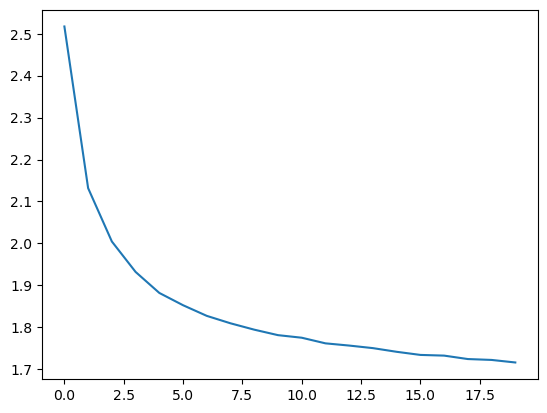

In [23]:
training_loss=loss[-1]
plt.plot(loss)
print(training_loss)

In [24]:
save_model(model,"transformer_weights.npy")

In [25]:
load_model(model,"transformer_weights.npy")

In [30]:
test_ins,test_out=text_generate_batch(test_tokens,512,block_size)
logits=model.forward_prop(test_ins)
test_loss=cross_entropy_loss(logits,test_out)
print(test_loss.data)

2.065359976992283


A training loss of 1.7 and a validation loss of 2.07 indicates that the model has been able to learn some structure. We can see in the below example that the model has learned some common names such as 'Juliet' as well as how punctuation is supposed to be used. We can also see some common Shakespeare style words such as 'thy' as well as made up words such as 'asweelf'.

As with most deep learning models, we might be able to reduce loss by increasing model complexity, training for longer, learning rate scheduling and using more data, though my laptop couldn't handle any more due to hardware restraints. We can improve the models generalisation by using dropout and L2 regularisation (AdamW).

In [33]:
iterations=1
prompt="Juliet! "

for i in range(iterations):
    print(generate_text(model,prompt,encode_dict,decode_dict,500,block_size))

Juliet! It plain the graretch ligh lone of uspeak'd.
That you foncesirace thereudish insuroad aild thy to good a asweelf,
Take the he bity lack hanow.

KING RICHARD IIIS:
Whele letn not know to thee
And then two reg.

Firds must a to die my out to mity of fied
thes of, and zerease cantagrand a,
To othingle days way, let your best grow's and
One am-palive with daying; andst sie!

AUn I thy grook to begue, batter him the must beeem orse,
Hathee crapmons wrich.

Nurt;
Sirness eye law take gething? duke the
